In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [9]:
IBM_attr = pd.read_csv('IBM-HR-Employee-Attrition.csv')

In [11]:
IBM_attr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [86]:
# Set display option to show all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the DataFrame
IBM_attr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [33]:
IBM_attr.shape

(1470, 35)

In [12]:
IBM_attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [13]:
IBM_attr.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [37]:
IBM_attr.corr()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


In [21]:
IBM_attr_sel = IBM_attr[['JobSatisfaction', 'HourlyRate', 'DistanceFromHome', 'Education', 'JobInvolvement']]

In [44]:
# Selecting relevant features from the dataset
IBM_attr_sel = IBM_attr[['JobSatisfaction', 'HourlyRate', 'DistanceFromHome', 'Education', 'JobInvolvement']]
# Defining the model
model = LogisticRegression()
# Defining the target variable 'y' and the features 'X'
y = IBM_attr_sel['JobSatisfaction']
X = IBM_attr_sel[['HourlyRate', 'DistanceFromHome', 'Education', 'JobInvolvement']]
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)
# Fitting the model
model.fit(X_train, y_train)
# Making predictions (use X_train, not y_train)
y_pred = model.predict(X_train)
# Evaluating the model
model_score = model.score(X_train, y_train)
print(f"Training accuracy: {model_score}")
print(y_pred)

Training accuracy: 0.3176043557168784
[4 4 3 ... 4 3 3]


C:\Users\ashut\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

In [61]:
regressor = RandomForestRegressor(n_estimators=1470, random_state=0)

In [79]:
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1470, oob_score=True, random_state=0)

In [80]:
predictions = regressor.predict(X)

In [52]:
from sklearn.metrics import mean_squared_error, r2_score, 

In [53]:
mse = mean_squared_error(y, predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.2635028710039144


In [54]:
r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

R-squared: 0.7832041079220047


In [81]:
X_grid = np.arange(min(X),max(X),0.01)
X_grid = X_grid.reshape(len(X_grid),1) 
   
plt.scatter(X,y, color='blue') #plotting real points
plt.plot(X_grid, regressor.predict(X_grid),color='green') #plotting for predict points
   
plt.title("Random Forest Regression Results")
plt.xlabel('HourlyRate', 'DistanceFromHome', 'Education', 'JobInvolvement')
plt.ylabel('Job_Satisfaction')
plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [76]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [73]:
X_grid = np.arange(min(X),max(X),0.01)
X_grid = X_grid.reshape(len(X_grid),1) 

features = ['HourlyRate', 'DistanceFromHome', 'Education', 'JobInvolvement']
for feature in features:
    plt.scatter(X[feature], y, color='blue')  # Replace X with X[feature] if X is a DataFrame
    plt.plot(X_grid, regressor.predict(X_grid), color='green')
    plt.title(f"Random Forest Regression Results for {feature}")
    plt.xlabel(feature)
    plt.ylabel('Job_Satisfaction')
    plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [75]:
X_feature = pd.to_numeric(X[feature], errors='raise').values.reshape(-1, 1)
# Create a grid for the current feature
X_grid = np.arange(min(X_feature), max(X_feature), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
for feature in features:
    X_feature = X[[feature]]  # Ensure X_feature is a 2D array for the model
    X_grid = np.arange(min(X_feature), max(X_feature), 0.01)  # Create a grid for the current feature
    X_grid = X_grid.reshape((len(X_grid), 1))
    
    plt.scatter(X_feature, y, color='blue')  # Plotting real points
    plt.plot(X_grid, regressor.predict(X_grid), color='green')  # Plotting prediction points
    plt.title(f"Random Forest Regression Results for {feature}")
    plt.xlabel(feature)
    plt.ylabel('Job_Satisfaction')
    plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [77]:
print(X.dtypes)
print(y.dtypes)

HourlyRate          int64
DistanceFromHome    int64
Education           int64
JobInvolvement      int64
dtype: object
int64


ValueError: Number of features of the model must match the input. Model n_features is 4 and input n_features is 1 

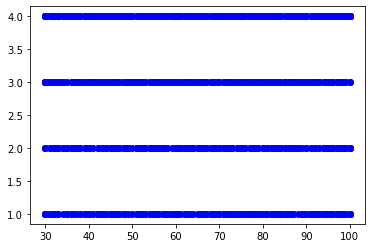

In [82]:
X_grid = np.arange(min(X.iloc[:, 0]), max(X.iloc[:, 0]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid, regressor.predict(X_grid), color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('HourlyRate')
plt.ylabel('Job_Satisfaction')
plt.show()

In [83]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Creating a grid for each feature
X_grid = np.arange(min(X.iloc[:, 0]), max(X.iloc[:, 0]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Creating a meshgrid for all features
X1, X2, X3, X4 = np.meshgrid(
    np.arange(min(X.iloc[:, 0]), max(X.iloc[:, 0]), 0.01),
    np.arange(min(X.iloc[:, 1]), max(X.iloc[:, 1]), 0.01),
    np.arange(min(X.iloc[:, 2]), max(X.iloc[:, 2]), 0.01),
    np.arange(min(X.iloc[:, 3]), max(X.iloc[:, 3]), 0.01)
)

# Flattening the meshgrid and combining into a single input array
X_grid = np.c_[X1.ravel(), X2.ravel(), X3.ravel(), X4.ravel()]

# Making predictions
y_pred = regressor.predict(X_grid)

# Reshaping the predictions to match the grid shape
y_pred = y_pred.reshape(X1.shape)

# Plotting the results
plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid[:, 0], y_pred, color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('HourlyRate')
plt.ylabel('Job_Satisfaction')
plt.show()

MemoryError: Unable to allocate 17.1 TiB for an array with shape (2800, 7000, 400, 300) and data type float64

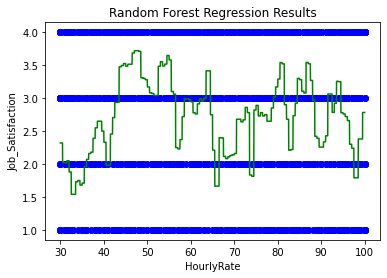

In [84]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Creating a grid for the first feature
X_grid = np.arange(min(X.iloc[:, 0]), max(X.iloc[:, 0]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Creating a DataFrame with the grid and constant values for other features
X_grid_full = np.tile(X_train.mean(axis=0).values, (len(X_grid), 1))
X_grid_full[:, 0] = X_grid[:, 0]

# Making predictions
y_pred = regressor.predict(X_grid_full)

# Plotting the results
plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid, y_pred, color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('HourlyRate')
plt.ylabel('Job_Satisfaction')
plt.show()

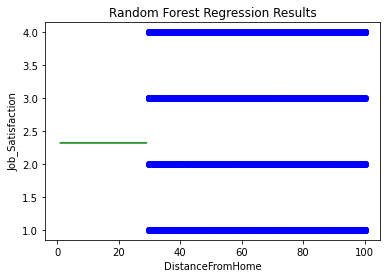

In [91]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Creating a grid for the first feature
X_grid = np.arange(min(X.iloc[:, 1]), max(X.iloc[:, 1]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Creating a DataFrame with the grid and constant values for other features
X_grid_full = np.tile(X_train.mean(axis=0).values, (len(X_grid), 1))
X_grid_full[:, 0] = X_grid[:, 0]

# Making predictions
y_pred = regressor.predict(X_grid_full)

# Plotting the results
plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid, y_pred, color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('DistanceFromHome')
plt.ylabel('Job_Satisfaction')
plt.show()

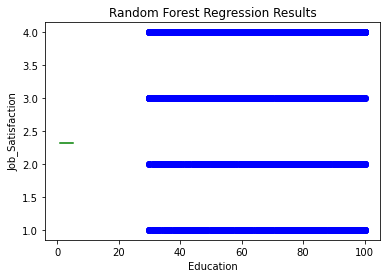

In [88]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Creating a grid for the first feature
X_grid = np.arange(min(X.iloc[:, 2]), max(X.iloc[:, 2]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Creating a DataFrame with the grid and constant values for other features
X_grid_full = np.tile(X_train.mean(axis=0).values, (len(X_grid), 1))
X_grid_full[:, 0] = X_grid[:, 0]

# Making predictions
y_pred = regressor.predict(X_grid_full)

# Plotting the results
plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid, y_pred, color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('Education')
plt.ylabel('Job_Satisfaction')
plt.show()

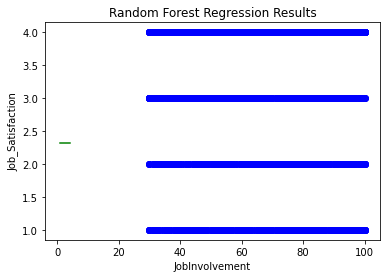

In [89]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Creating a grid for the first feature
X_grid = np.arange(min(X.iloc[:, 3]), max(X.iloc[:, 3]), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Creating a DataFrame with the grid and constant values for other features
X_grid_full = np.tile(X_train.mean(axis=0).values, (len(X_grid), 1))
X_grid_full[:, 0] = X_grid[:, 0]

# Making predictions
y_pred = regressor.predict(X_grid_full)

# Plotting the results
plt.scatter(X.iloc[:, 0], y, color='blue')  # plotting real points
plt.plot(X_grid, y_pred, color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('JobInvolvement')
plt.ylabel('Job_Satisfaction')
plt.show()